In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../")

from src.pipeline.data_loader import load_data
from src.pipeline.preprocessor import preprocess_pipeline
from src.features.feature_engineering import run_feature_engineering
from src.models.train_model import train_all_models, save_models
from src.models.evaluate_model import (
    evaluate_all_models, plot_roc_curves,
    plot_confusion_matrix, plot_feature_importance
)
from src.config import (
    PROCESSED_DATA_FILE, TARGET_COLUMN,
    TEST_SIZE, RANDOM_STATE
)
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_theme(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Load & preprocess
df           = load_data()
preprocess_pipeline(df)

# Enrich features
processed_df = pd.read_csv(PROCESSED_DATA_FILE)
enriched_df  = run_feature_engineering(processed_df)

# Split
drop_cols    = [TARGET_COLUMN, "customer_id"]
feature_cols = [c for c in enriched_df.columns if c not in drop_cols]

X = enriched_df[feature_cols].fillna(0)
y = enriched_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"✅ Train size : {len(X_train)}")
print(f"✅ Test size  : {len(X_test)}")
print(f"✅ Features   : {len(feature_cols)}")

✅ Loading data from: c:\Users\HP\churn_prediction_system\data\raw\customers.csv

🧹 STARTING PREPROCESSING PIPELINE
🔧 Handling missing values...
   ✅ Missing values after fix: 0
🔧 Removed 0 duplicate rows.
🔧 Encoding categorical columns...
   ✅ Encoded: gender
   ✅ Encoded: contract_type
   ✅ Encoded: payment_method
   ✅ Encoded: internet_service
🔧 Scaling numerical columns...
   ✅ Scaler saved to: c:\Users\HP\churn_prediction_system\models\scaler.pkl

✅ Processed data saved to: c:\Users\HP\churn_prediction_system\data\processed\customers_processed.csv
🔧 Splitting data into train/test sets...
   ✅ Train size: 800 | Test size: 200

✅ PREPROCESSING COMPLETE!


⚡ STARTING FEATURE ENGINEERING
⚡ Adding RFM features...
   ✅ RFM features added!
⚡ Adding engagement features...
   ✅ Engagement features added!
⚡ Adding risk features...
   ✅ Risk features added!
⚡ Adding CLV segments...
   ✅ CLV segments added!

✅ Enriched data saved to: c:\Users\HP\churn_prediction_system\data\processed\customers

In [3]:
trained_models = train_all_models(X_train, y_train)
save_models(trained_models)
print("\n✅ All models trained and saved!")


🤖 TRAINING ALL MODELS
⚖️  Applying SMOTE to balance classes...
   Before SMOTE: {1: np.int64(478), 0: np.int64(322)}
   After SMOTE : {1: np.int64(478), 0: np.int64(478)}

🔄 Training: Logistic Regression...
   ✅ Logistic Regression trained!

🔄 Training: Random Forest...
   ✅ Random Forest trained!

🔄 Training: XGBoost...
   ✅ XGBoost trained!

🔄 Training: LightGBM...
   ✅ LightGBM trained!
   💾 Saved: logistic_regression.pkl
   💾 Saved: random_forest.pkl
   💾 Saved: xgboost.pkl
   💾 Saved: lightgbm.pkl

✅ All models trained and saved!


In [4]:
results_df = evaluate_all_models(trained_models, X_test, y_test)
results_df


📊 EVALUATING ALL MODELS

✅ Logistic Regression
   Accuracy : 0.835
   F1 Score : 0.8619
   ROC-AUC  : 0.9299

✅ Random Forest
   Accuracy : 0.98
   F1 Score : 0.9833
   ROC-AUC  : 0.998

✅ XGBoost
   Accuracy : 0.99
   F1 Score : 0.9917
   ROC-AUC  : 0.9999

✅ LightGBM
   Accuracy : 0.99
   F1 Score : 0.9917
   ROC-AUC  : 0.9998

🏆 FINAL LEADERBOARD
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost     0.990     0.9917  0.9917    0.9917   0.9999
           LightGBM     0.990     0.9917  0.9917    0.9917   0.9998
      Random Forest     0.980     0.9833  0.9833    0.9833   0.9980
Logistic Regression     0.835     0.8655  0.8583    0.8619   0.9299


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.990,0.9917,0.9917,0.9917,0.9999
3,LightGBM,0.990,0.9917,0.9917,0.9917,0.9998
1,Random Forest,0.980,0.9833,0.9833,0.9833,0.9980
0,Logistic Regression,0.835,0.8655,0.8583,0.8619,0.9299


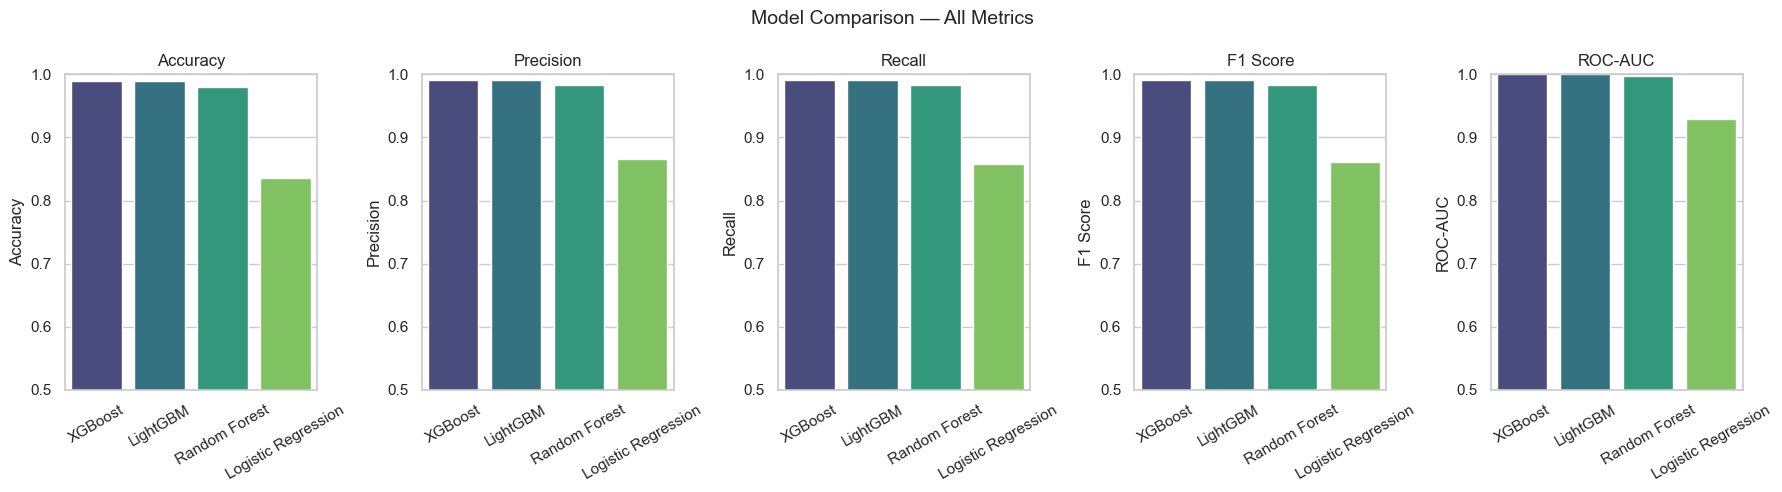

In [5]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, metric in enumerate(metrics):
    sns.barplot(
        data=results_df,
        x="Model", y=metric,
        hue="Model", legend=False,
        palette="viridis", ax=axes[i]
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_xlabel("")

plt.suptitle("Model Comparison — All Metrics", fontsize=14)
plt.tight_layout()
plt.show()

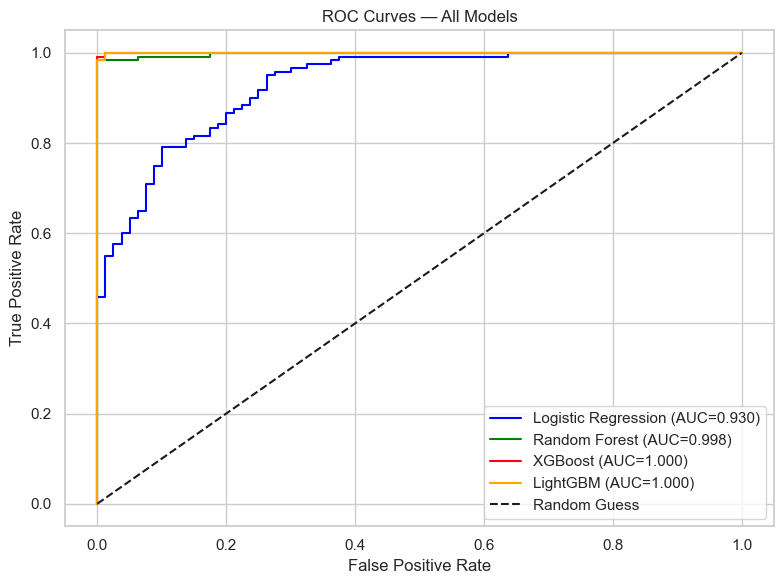

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

colors = ["blue", "green", "red", "orange"]

for (name, model), color in zip(trained_models.items(), colors):
    X_clean  = X_test.fillna(0)
    y_prob   = model.predict_proba(X_clean)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc      = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.show()

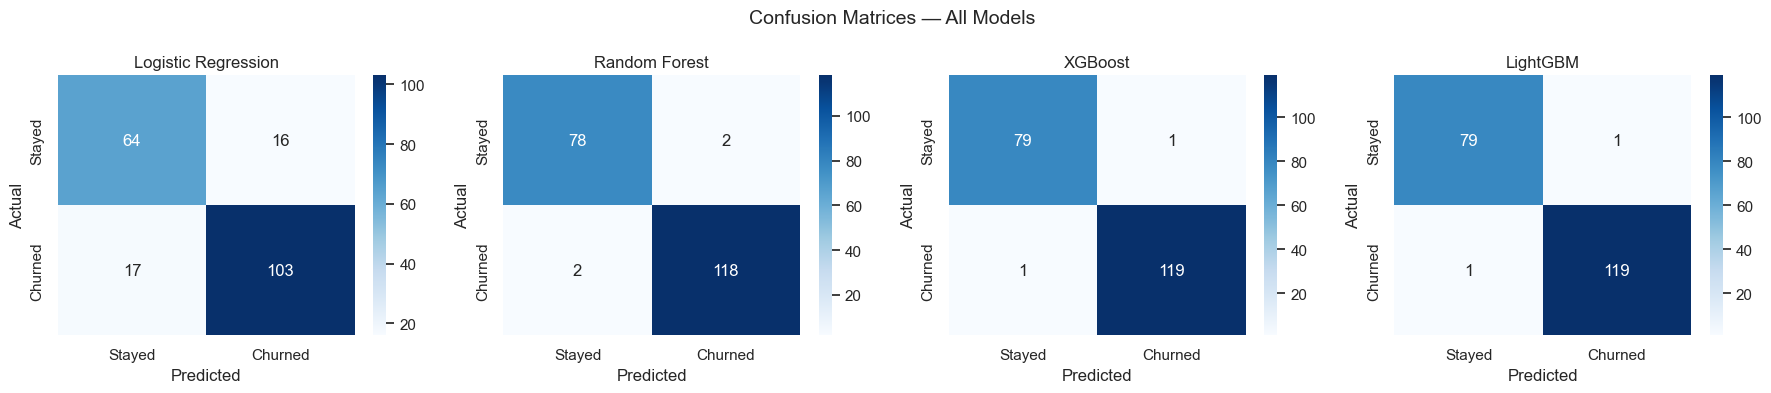

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

from sklearn.metrics import confusion_matrix

for ax, (name, model) in zip(axes, trained_models.items()):
    X_clean = X_test.fillna(0)
    y_pred  = model.predict(X_clean)
    cm      = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues", ax=ax,
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=14)
plt.tight_layout()
plt.show()

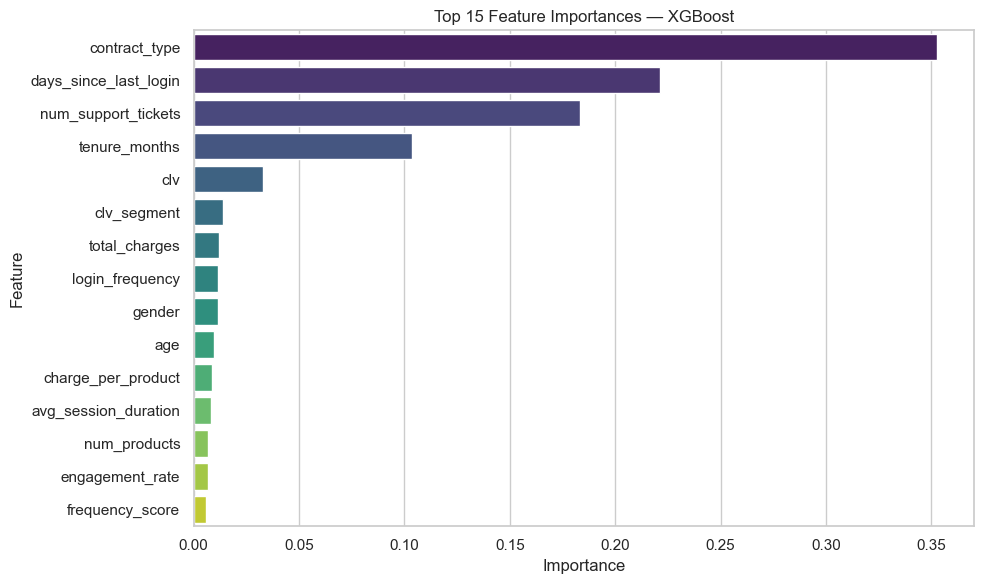


🔝 Top 10 Most Important Features:
              Feature  Importance
        contract_type    0.352641
days_since_last_login    0.221279
  num_support_tickets    0.183389
        tenure_months    0.103395
                  clv    0.033133
          clv_segment    0.013887
        total_charges    0.011806
      login_frequency    0.011619
               gender    0.011421
                  age    0.009747


In [9]:
xgb_model    = trained_models["XGBoost"]
importance_df = pd.DataFrame({
    "Feature"   : feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="Importance", y="Feature",
    hue="Feature", legend=False,
    palette="viridis"
)
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

print("\n🔝 Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

In [10]:
best_model = results_df.iloc[0]

print("="*55)
print("🏆 BEST MODEL")
print("="*55)
print(f"🥇 Model     : {best_model['Model']}")
print(f"📊 Accuracy  : {best_model['Accuracy']}")
print(f"🎯 F1 Score  : {best_model['F1 Score']}")
print(f"📈 ROC-AUC   : {best_model['ROC-AUC']}")
print("="*55)
print("\n✅ Model is saved and ready for production!")

🏆 BEST MODEL
🥇 Model     : XGBoost
📊 Accuracy  : 0.99
🎯 F1 Score  : 0.9917
📈 ROC-AUC   : 0.9999

✅ Model is saved and ready for production!
